# Credit Card Fraud Detection

This notebook follows the CS770 project proposal using only the two selected datasets:

- `fraudTrain.csv`
- `fraudTest.csv`

The goal is binary classification: predict whether a credit card transaction is fraud or not fraud.

## Project Plan

The proposal says to compare Random Forest and Logistic Regression, account for class imbalance, use dimensionality reduction with PCA, and report accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC.

This notebook is organized around those exact steps.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 67

sns.set_theme(style="whitegrid")

## 1. Load the Two Selected Datasets

In [10]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CANDIDATES = [PROJECT_ROOT / "datasets", PROJECT_ROOT.parent / "datasets"]
DATA_DIR = next(
    (
        path
        for path in DATA_CANDIDATES
        if (path / "fraudTrain.csv").exists() and (path / "fraudTest.csv").exists()
    ),
    DATA_CANDIDATES[0],
)

TRAIN_PATH = DATA_DIR / "fraudTrain.csv"
TEST_PATH = DATA_DIR / "fraudTest.csv"

print("Training data path:", TRAIN_PATH)
print("Testing data path:", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
train_df.head()

Training data path: /Users/minhtran/Desktop/College stuff/8th Semester (Spring 2026)/Machine Learning (CS770)/Fraud-Detector/datasets/fraudTrain.csv
Testing data path: /Users/minhtran/Desktop/College stuff/8th Semester (Spring 2026)/Machine Learning (CS770)/Fraud-Detector/datasets/fraudTest.csv
train shape: (1296675, 23)
test shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [11]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

## 2. Initial Analysis: Class Imbalance

Fraud detection datasets are usually highly imbalanced, meaning most transactions are not fraud. Because of that, accuracy alone can be misleading. Precision, recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix are more useful.

In [12]:
def show_class_balance(df, label="dataset"):
    counts = df["is_fraud"].value_counts().sort_index()
    percents = df["is_fraud"].value_counts(normalize=True).sort_index() * 100
    balance = pd.DataFrame({"count": counts, "percent": percents.round(4)})
    balance.index = ["not fraud", "fraud"]
    print(label)
    display(balance)
    return balance

train_balance = show_class_balance(train_df, "Training set")
test_balance = show_class_balance(test_df, "Testing set")

Training set


,count,percent
not fraud,1289169,99.4211
fraud,7506,0.5789


Testing set


,count,percent
not fraud,553574,99.614
fraud,2145,0.386


/var/folders/bs/84lrzm4j3bz1b02qykxt4bzc0000gn/T/ipykernel_13753/2773295923.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not fraud", "fraud"])
/var/folders/bs/84lrzm4j3bz1b02qykxt4bzc0000gn/T/ipykernel_13753/2773295923.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not fraud", "fraud"])


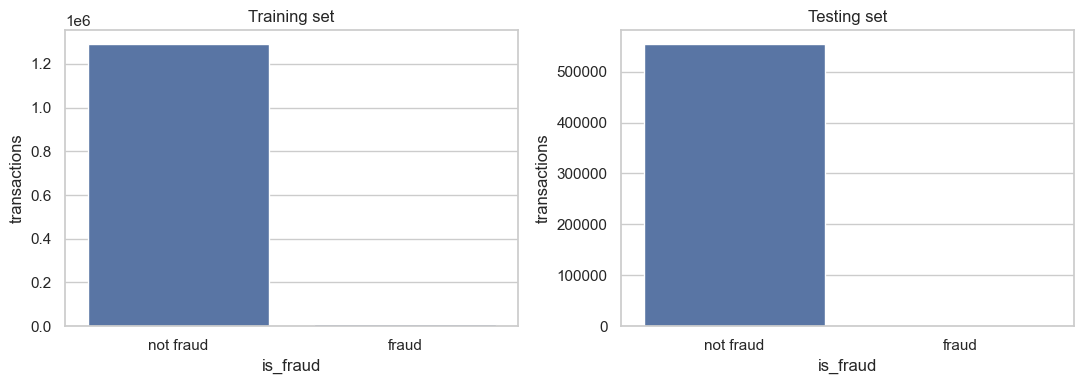

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, title in [
    (axes[0], train_df, "Training set"),
    (axes[1], test_df, "Testing set"),
]:
    sns.countplot(data=df, x="is_fraud", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("is_fraud")
    ax.set_ylabel("transactions")
    ax.set_xticklabels(["not fraud", "fraud"])

plt.tight_layout()

## 3. Feature Engineering

The original dataset contains identifiers and personally identifying text fields that are not good model inputs. This section keeps useful transaction features and creates date-based features like transaction hour, day of week, and cardholder age.

In [14]:
def add_time_features(df):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25

    return df

train_features_df = add_time_features(train_df)
test_features_df = add_time_features(test_df)

feature_columns = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "transaction_hour",
    "transaction_dayofweek",
    "transaction_month",
    "age",
    "category",
    "gender",
]

target_column = "is_fraud"

X_train_full = train_features_df[feature_columns]
y_train_full = train_features_df[target_column]
X_test_full = test_features_df[feature_columns]
y_test_full = test_features_df[target_column]

X_train_full.head()

,amt,lat,long,city_pop,merch_lat,merch_long,transaction_hour,transaction_dayofweek,transaction_month,age,category,gender
0,4.97,36.0788,-81.1781,3495,36.011293,-82.048315,0,1,1,30.814511,misc_net,F
1,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,1,1,40.531143,grocery_pos,F
2,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,1,1,56.950034,entertainment,M
3,45.00,46.2306,-112.1138,1939,47.034331,-112.561071,0,1,1,51.969884,gas_transport,M
4,41.96,38.4207,-79.4629,99,38.674999,-78.632459,0,1,1,32.763860,misc_pos,M


## 4. Optional Sampling for Faster Notebook Runs

The full Kaggle training set is large. Set `USE_SAMPLE = False` for final project results. During development, the stratified sample below keeps the fraud/not-fraud ratio similar while making the notebook faster.

In [15]:
USE_SAMPLE = True
TRAIN_SAMPLE_SIZE = 50_000
TEST_SAMPLE_SIZE = 25_000

def stratified_sample(X, y, sample_size, random_state=RANDOM_STATE):
    if (not USE_SAMPLE) or len(X) <= sample_size:
        return X.copy(), y.copy()

    _, X_sample, _, y_sample = train_test_split(
        X,
        y,
        test_size=sample_size,
        stratify=y,
        random_state=random_state,
    )
    return X_sample.reset_index(drop=True), y_sample.reset_index(drop=True)

X_train, y_train = stratified_sample(X_train_full, y_train_full, TRAIN_SAMPLE_SIZE)
X_test, y_test = stratified_sample(X_test_full, y_test_full, TEST_SAMPLE_SIZE)

print("training shape:", X_train.shape)
print("testing shape:", X_test.shape)
show_class_balance(pd.DataFrame({target_column: y_train}), "Model training set")
show_class_balance(pd.DataFrame({target_column: y_test}), "Model testing set")

training shape: (50000, 12)
testing shape: (25000, 12)
Model training set


,count,percent
not fraud,49711,99.422
fraud,289,0.578


Model testing set


,count,percent
not fraud,24904,99.616
fraud,96,0.384


,count,percent
not fraud,24904,99.616
fraud,96,0.384


## 5. Preprocessing and PCA

Numeric features are imputed and standardized. Categorical features are imputed and one-hot encoded. PCA is then used for dimensionality reduction, matching the proposal.

In [16]:
def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

numeric_features = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "transaction_hour",
    "transaction_dayofweek",
    "transaction_month",
    "age",
]

categorical_features = ["category", "gender"]


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", build_one_hot_encoder()),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def build_pca():
    return PCA(n_components=0.95, random_state=RANDOM_STATE)

## 6. Train Logistic Regression and Random Forest

Both models use `class_weight="balanced"` to address the class imbalance noted in the proposal.

In [17]:
logistic_regression = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("pca", build_pca()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

random_forest = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("pca", build_pca()),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

In [18]:
models = {
    "Logistic Regression": logistic_regression,
    "Random Forest": random_forest,
}

fitted_models = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    print(f"Finished {model_name}")

Training Logistic Regression...
Finished Logistic Regression
Training Random Forest...
Finished Random Forest


In [19]:
for model_name, model in fitted_models.items():
    n_components = model.named_steps["pca"].n_components_
    explained_variance = model.named_steps["pca"].explained_variance_ratio_.sum()
    print(f"{model_name}: PCA kept {n_components} components explaining {explained_variance:.2%} variance")

Logistic Regression: PCA kept 12 components explaining 95.16% variance
Random Forest: PCA kept 12 components explaining 95.16% variance


## 7. Evaluation Metrics

The proposal lists accuracy, precision, recall, F1-score, confusion matrix, ROC, and AUC. Because this is imbalanced fraud detection, PR-AUC is included too.

In [20]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.50):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }

    print(f"\n{model_name}")
    print(classification_report(y_test, y_pred, target_names=["not fraud", "fraud"], zero_division=0))

    return metrics, y_pred, y_prob

results = []
predictions = {}

for model_name, model in fitted_models.items():
    metrics, y_pred, y_prob = evaluate_model(model_name, model, X_test, y_test)
    results.append(metrics)
    predictions[model_name] = {"y_pred": y_pred, "y_prob": y_prob}

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


Logistic Regression
              precision    recall  f1-score   support

   not fraud       1.00      0.95      0.97     24904
       fraud       0.05      0.76      0.10        96

    accuracy                           0.95     25000
   macro avg       0.53      0.85      0.54     25000
weighted avg       1.00      0.95      0.97     25000


Random Forest
              precision    recall  f1-score   support

   not fraud       1.00      1.00      1.00     24904
       fraud       0.90      0.38      0.53        96

    accuracy                           1.00     25000
   macro avg       0.95      0.69      0.76     25000
weighted avg       1.00      1.00      1.00     25000



,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.5,0.99744,0.90000,0.375000,0.529412,0.965816,0.660917
0,Logistic Regression,0.5,0.94636,0.05248,0.760417,0.098184,0.895637,0.162202


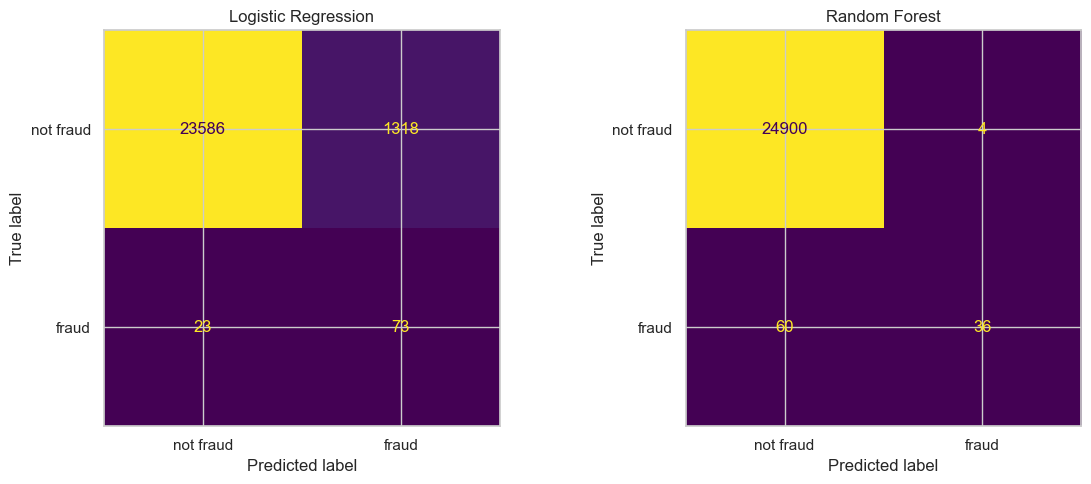

In [21]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 5))
if len(fitted_models) == 1:
    axes = [axes]

for ax, (model_name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not fraud", "fraud"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()

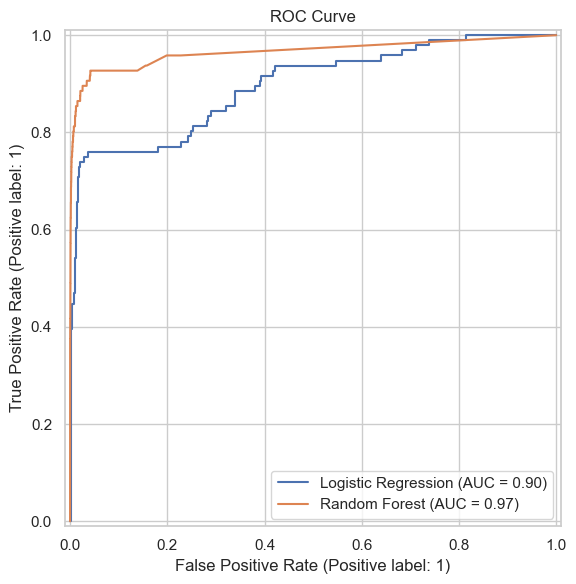

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.set_title("ROC Curve")
plt.tight_layout()

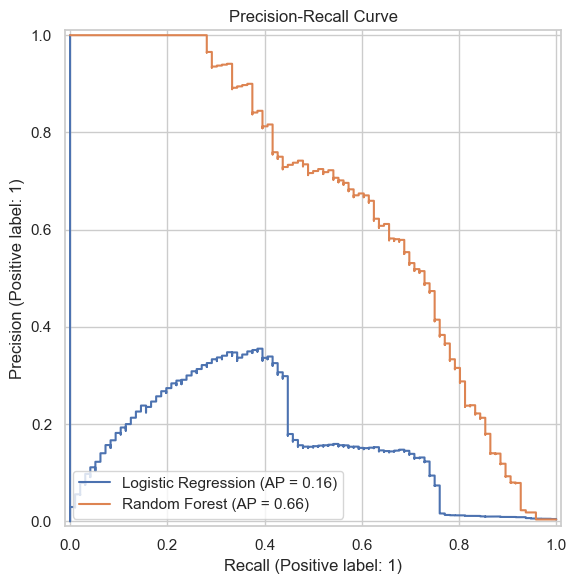

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.set_title("Precision-Recall Curve")
plt.tight_layout()

## 8. Threshold Tuning

Fraud detection usually cares about catching fraud cases without creating too many false alarms. The default threshold of 0.50 is not always best, so this section compares thresholds using precision, recall, and F1-score.

In [24]:
threshold_rows = []
thresholds = np.arange(0.05, 0.96, 0.05)

for model_name, preds in predictions.items():
    y_prob = preds["y_prob"]
    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)
        threshold_rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.sort_values(["model", "f1"], ascending=[True, False]).groupby("model").head(5)

,model,threshold,precision,recall,f1
18,Logistic Regression,0.95,0.277419,0.447917,0.342629
17,Logistic Regression,0.90,0.198157,0.447917,0.274760
15,Logistic Regression,0.80,0.156627,0.541667,0.242991
14,Logistic Regression,0.75,0.149871,0.604167,0.240166
13,Logistic Regression,0.70,0.143791,0.687500,0.237838
23,Random Forest,0.25,0.670455,0.614583,0.641304
22,Random Forest,0.20,0.603960,0.635417,0.619289
24,Random Forest,0.30,0.722222,0.541667,0.619048
21,Random Forest,0.15,0.523077,0.708333,0.601770
25,Random Forest,0.35,0.723077,0.489583,0.583851


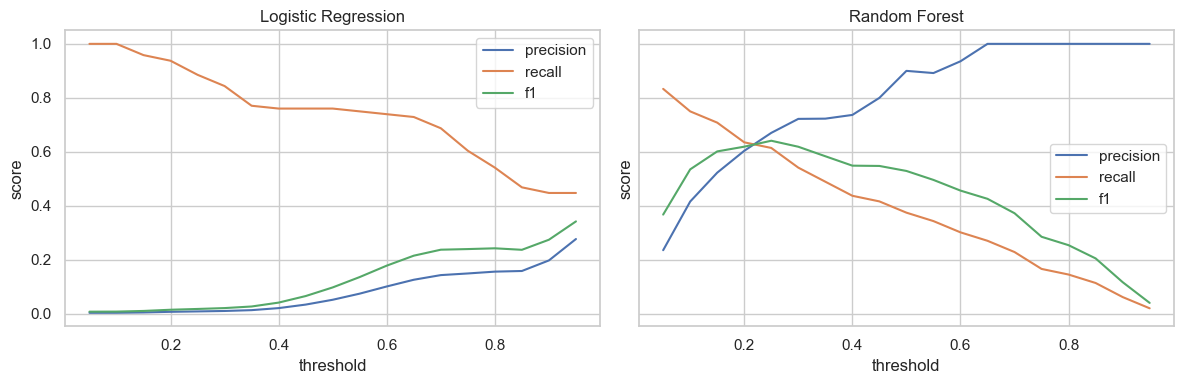

In [25]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 4), sharey=True)
if len(fitted_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, fitted_models.keys()):
    subset = threshold_df[threshold_df["model"] == model_name]
    ax.plot(subset["threshold"], subset["precision"], label="precision")
    ax.plot(subset["threshold"], subset["recall"], label="recall")
    ax.plot(subset["threshold"], subset["f1"], label="f1")
    ax.set_title(model_name)
    ax.set_xlabel("threshold")
    ax.set_ylabel("score")
    ax.legend()

plt.tight_layout()

## 9. Optional Grid Search

Run this section if there is enough time. It tunes a small Random Forest parameter grid using ROC-AUC. For final results, keep sampling off and expect this to take longer.

In [26]:
RUN_GRID_SEARCH = False

if RUN_GRID_SEARCH:
    rf_grid = Pipeline(steps=[
        ("preprocess", build_preprocessor()),
        ("pca", build_pca()),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2, 5],
    }

    grid_search = GridSearchCV(
        estimator=rf_grid,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print("best score:", grid_search.best_score_)
    print("best params:", grid_search.best_params_)
else:
    print("Grid search skipped. Set RUN_GRID_SEARCH = True to run it.")

Grid search skipped. Set RUN_GRID_SEARCH = True to run it.


## 10. Notes for Final Report

Use the results table, confusion matrices, ROC curve, and precision-recall curve when writing the report. Since the dataset is imbalanced, emphasize precision, recall, F1-score, PR-AUC, and confusion matrix more than raw accuracy.